## Impact of FSI and Turbulence ##

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

import importlib
import postprocessing_functions as pp
importlib.reload(pp)

<module 'postprocessing_functions' from '/kfs2/projects/pvopt/aps_dfd_2024/PVade/postprocessing/postprocessing_functions.py'>

In [98]:
# copying from https://github.com/brookeslawski/scripts/blob/main/pvade-pproc-aps2024.ipynb
# parentdir = '/scratch/bstanisl/pvade/turb_inflow/'
parentdir = '/projects/solarflow/bstanisl/turb_inflow/'

casepath_prefix = 'halfwing'

# cases = ['FSI','noFSI']
# cases_fnames = {'FSI':'turbinflow', 'noFSI':'turbinflow_noFSI'}

cases = ['turb_inflow','no_turb']
cases_fnames = {'turb_inflow':'turbinflow', 'no_turb':'noturb'}

tilt = 40.0

casepaths = {}
exp_data_fns = {}

for case in cases:
    # casepaths[case] = {}
    # for case in cases:
    casepath = f'{casepath_prefix}_{cases_fnames[case]}_duramat_validation_{tilt}deg/'
    casepaths[case] = casepath

    exp_data_fn = f'DuraMAT_tilt{int(tilt)}deg_turbulent_inflow_10min_timeseries.csv'
    exp_data_fns[case] = exp_data_fn
    
    del casepath
    del exp_data_fn
casepaths

{'turb_inflow': 'halfwing_turbinflow_duramat_validation_40.0deg/',
 'no_turb': 'halfwing_noturb_duramat_validation_40.0deg/'}

In [99]:
exp_data_fns

{'turb_inflow': 'DuraMAT_tilt40deg_turbulent_inflow_10min_timeseries.csv',
 'no_turb': 'DuraMAT_tilt40deg_turbulent_inflow_10min_timeseries.csv'}

In [100]:
# read in lift and drag
loadsdata = {}
for case in cases:
    print(case)
    loadsdata[case] = {}
    output_dir=parentdir+'output/'+casepaths[case]
    loadsdata[case] = pp.read_pvade_csv(output_dir)
    
loadsdata[case]

turb_inflow
no_turb


,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,def-x,def-y,def-z
Time,,,,,,,,,,,,
0.006,98222.574200,-1.155066,116639.213300,45.097665,-0.000530,53.553434,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.012,15782.133540,-6.799526,16739.257550,7.246169,-0.003122,7.685621,26.605580,-5.507530,39.200737,0.000345,-0.000071,0.000508
0.018,-1697.833932,-6.671649,-4185.565445,-0.779539,-0.003063,-1.921750,155.453675,3.304253,165.304176,0.003164,-0.000195,0.003836
0.024,3525.146732,-9.283204,3466.678129,1.618527,-0.004262,1.591682,187.036566,3.768127,186.329680,0.011247,-0.000245,0.012661
0.030,6133.981779,-16.972021,6599.498699,2.816341,-0.007792,3.030077,-120.839827,0.602422,-110.018719,0.021891,-0.000202,0.024232
...,...,...,...,...,...,...,...,...,...,...,...,...
29.976,2195.997561,-3.173682,2388.534536,1.008265,-0.001457,1.096666,0.031191,0.000551,0.035595,-0.027639,-0.000174,-0.032494
29.982,2195.944831,-3.184647,2388.649983,1.008241,-0.001462,1.096719,0.025694,0.000330,0.029307,-0.027619,-0.000174,-0.032471
29.988,2195.701273,-3.151882,2388.237285,1.008129,-0.001447,1.096529,0.020138,0.000136,0.022962,-0.027599,-0.000174,-0.032447


In [101]:
# read input parameters
params = {}
for case in cases:
    params[case] = {}
    output_dir=parentdir+'output/'+casepaths[case]
    params[case] = pp.read_params(output_dir)

params[case]

{'tracker_angle': 40.0,
 'dt_sim': 0.006,
 'dt_xdmf': 0.012,
 'panel_span': 13.07,
 'panel_chord': 4.1,
 'panel_height': 2.1,
 'tf': 30.0,
 'z_max': 20.0}

In [110]:
cases

['turb_inflow', 'no_turb']

In [114]:
np.shape(readdata[case]['u'])

(2501, 131, 65, 50)

In [120]:
np.inf

inf

In [121]:
# read velocity data
readdata = {}
coords = {}

nt_min = np.inf #np.shape(readdata[cases[0]]['u'])
for j, case in enumerate(cases):
    readdata[case] = {}
    coords[case] = {}
    
    if (case == 'FSI') or (case == 'turb_inflow'):
        pkl_fname = f'duramatval_tracker_angle_{tilt}.pkl'
    else: 
        pkl_fname = f'duramatval_{cases_fnames[case]}_tracker_angle_{tilt}.pkl'
    pkl_path = parentdir+'interp_data/timeseries_data/'+pkl_fname

    print('reading from', pkl_path)

    readdata[case], coords[case] = pp.read_pvade_output_pkl(pkl_path)
    nt_tmp = np.shape(readdata[case]['u'])[0]
    
    if nt_tmp < nt_min:
        nt_min = nt_tmp
        # print(nt_min)

reading from /projects/solarflow/bstanisl/turb_inflow/interp_data/timeseries_data/duramatval_tracker_angle_40.0.pkl
vel data nt, nx, ny, nz =  (2484, 131, 65, 50)
coord nx, ny, nz =  (131, 65, 50)
2484
reading from /projects/solarflow/bstanisl/turb_inflow/interp_data/timeseries_data/duramatval_noturb_tracker_angle_40.0.pkl
vel data nt, nx, ny, nz =  (2501, 131, 65, 50)
coord nx, ny, nz =  (131, 65, 50)


In [122]:
# check if num of timesteps is equal among cases and trim if needed
for case in cases:
    # trim
    for comp in readdata[case].keys():
        readdata[case][comp] = readdata[case][comp][:nt_min, :, :, :]
    print('vel data nt, nx, ny, nz = ', np.shape(readdata[case]['u']))

ndim = len(np.shape(readdata[case]['u']))

vel data nt, nx, ny, nz =  (2484, 131, 65, 50)
vel data nt, nx, ny, nz =  (2484, 131, 65, 50)


In [123]:
# assumes the same grid cell locations for all cases
xi = coords[case]['X'][:,0,0]
yi = coords[case]['Y'][0,:,0]
zi = coords[case]['Z'][0,0,:]

# sonic location
[xloc, yloc, zloc] = [-12.36, 4.5, 2.23]

In [124]:
# velocity signal at sonic location
i = int(np.argmin(np.abs(xi - xloc)))
j = int(np.argmin(np.abs(yi - yloc)))
k = int(np.argmin(np.abs(zi - zloc)))
# print(f'sonic loc indices = {i, j, k}')

vel_data = {}
for case in cases:
    # create dataframe from velocity data
    nt = np.shape(readdata[case]['u'])[0]
    time_xdmf = np.arange(params[case]['dt_xdmf'], params[case]['tf']+params[case]['dt_xdmf'], params[case]['dt_xdmf'])[0:nt] #np.linspace(dt_xdmf, tf, nt)

    vel_data[case] = pd.DataFrame(index=time_xdmf)
    for comp in ['u', 'v', 'w']:
        vel_data[case][comp+' (m/s)'] = readdata[case][comp][:,0,j,k]


In [125]:
# merge sim data
sim_data = {}
for case in cases:
    sim_data[case] = {}
    sim_data[case] = pd.merge(loadsdata[case], vel_data[case], left_index=True, right_index=True, how='inner')
sim_data[case]

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,def-x,def-y,def-z,u (m/s),v (m/s),w (m/s)
0.012,15782.133540,-6.799526,16739.257550,7.246169,-0.003122,7.685621,26.605580,-5.507530,39.200737,0.000345,-0.000071,0.000508,NaN,NaN,NaN
0.024,3525.146732,-9.283204,3466.678129,1.618527,-0.004262,1.591682,187.036566,3.768127,186.329680,0.011247,-0.000245,0.012661,NaN,NaN,NaN
0.048,13220.935460,-39.596292,15375.840050,6.070227,-0.018180,7.059624,142.912485,-0.167965,181.589589,0.023408,-0.000009,0.026709,NaN,NaN,NaN
0.060,4386.129306,-14.990491,4845.935984,2.013836,-0.006883,2.224951,-248.984273,-5.989251,-205.309270,0.022565,-0.000018,0.024659,NaN,NaN,NaN
0.072,5977.278228,-6.570185,6998.639179,2.744392,-0.003017,3.213338,104.684343,-4.117174,159.623451,0.004919,0.000003,0.005047,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.736,2188.511457,-3.860952,2379.266935,1.004828,-0.001773,1.092411,0.022953,0.000015,0.026287,-0.027383,-0.000171,-0.032199,9.095479,2.449864e-06,1.535681e-06
29.748,2189.415315,-3.863286,2380.242991,1.005243,-0.001774,1.092859,0.024531,0.000230,0.028386,-0.027437,-0.000172,-0.032260,9.095483,3.010667e-06,3.182757e-06
29.760,2190.411853,-3.862144,2381.348138,1.005700,-0.001773,1.093366,0.025769,0.000168,0.029763,-0.027487,-0.000172,-0.032318,9.095488,2.934981e-06,2.085927e-06
29.796,2193.380997,-3.864651,2384.718593,1.007063,-0.001774,1.094914,0.030795,0.000261,0.035390,-0.027614,-0.000173,-0.032464,9.095486,8.041663e-07,-2.658769e-06


In [126]:
# calculate lift and drag coeff
for case in cases:
    sfc_area = params[case]['panel_span'] * params[case]['panel_chord']
    sim_data[case]['vel_mag (m/s)'] = pp.calc_magnitude(sim_data[case])
    sim_data[case]['fx_nd_calc'] = pp.calc_force_coefficient(sim_data[case]['fx_0'], sim_data[case]['vel_mag (m/s)'], sfc_area)
    sim_data[case]['fz_nd_calc'] = pp.calc_force_coefficient(sim_data[case]['fz_0'], sim_data[case]['vel_mag (m/s)'], sfc_area)
    # sim_data[case]['fx_nd_calc'] = (sim_data[case]['fx_0'])/(0.5*1*sim_data[case]['vel_mag (m/s)']**2*sfc_area)
    # sim_data[case]['fz_nd_calc'] = (sim_data[case]['fz_0'])/(0.5*1*sim_data[case]['vel_mag (m/s)']**2*sfc_area)

In [128]:
cases

['turb_inflow', 'no_turb']

In [129]:
# read in experimental data
exp_data = {}
t0_sonic1 = {}
tf_sonic1 = {}

case = cases[0]

t0_sonic1[case], tf_sonic1[case], tmp_exp_data = pp.read_exp_csv_data(exp_data_fns[case])
tf_sim = sim_data[case].index[-1]
exp_data['exp'] = pp.cut_exp_signal(tilt, t0_sonic1[case], tf_sim, tmp_exp_data)

dt_exp = exp_data['exp'].index[1]-exp_data['exp'].index[0]
    
exp_data['exp']

start time of 40.0 case exp data =  2019-10-04 17:35:55
0.0


,3D wind speed (m/s),Wind direction (deg),u (m/s),v (m/s),w (m/s),temp (degC),Drive tracker angle (deg),Drive torque north (kNm),Panel defl mid (mm),Drag force (kN),Lift force (kN),Drag force tracker angle (kN),Lift force tracker angle (kN),AccNW X (g),AccNW Y (g),AccNE X (g),AccNE Y (g)
Time,,,,,,,,,,,,,,,,,
0.02,9.567942,270.04828,9.540954,0.008039,0.718082,14.153996,40.541090,-2.579051,2.677513,4.023743,4.795310,4.068848,4.757097,-0.050700,0.036745,-1.161277,0.635432
0.04,9.567616,270.04276,9.540588,0.007120,0.718604,14.154172,40.541640,-2.544011,2.768883,3.969075,4.730159,4.013612,4.692427,-0.045759,0.042331,-0.465499,0.625758
0.06,9.568180,270.03586,9.541167,0.005969,0.718446,14.155300,40.545723,-2.507620,2.833717,3.912299,4.662497,3.956530,4.625022,-0.128438,-0.012178,-0.807424,0.672569
0.08,9.568017,270.03380,9.541007,0.005632,0.718398,14.154648,40.539486,-2.425076,2.631208,3.783517,4.509019,3.825804,4.473195,-0.133445,-0.025662,-0.659689,0.699951
0.10,9.568154,270.04370,9.541139,0.007275,0.718469,14.155776,40.544342,-2.312586,2.490352,3.608014,4.299863,3.648701,4.265391,0.303243,0.025229,-0.657600,0.629614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,12.780877,262.78656,12.590276,-1.593523,-1.515404,14.300554,40.462505,-2.074871,2.672827,3.237139,3.857871,3.268174,3.831615,0.004986,-0.020440,-0.731875,0.692967
29.72,12.780626,262.78550,12.590027,-1.593730,-1.515144,14.299802,40.463005,-2.063795,2.636113,3.219859,3.837278,3.250762,3.811134,0.197785,0.007008,-0.840510,0.660998
29.74,12.780664,262.77560,12.589726,-1.595900,-1.515681,14.300103,40.462837,-2.040101,2.448396,3.182892,3.793223,3.213430,3.767388,0.108501,0.000030,-1.018290,0.663273


In [131]:
if 'AccNW X (g)' in exp_data['exp'].columns:
    print('yes')

yes


In [132]:
# calculate lift and drag force coefficients and fix accelerations

case = 'exp'

# for case in cases:
# exp_data[case]['Drag Coefficient'] = (exp_data[case]['Drag force (kN)']*1000)/(0.5*1*exp_data[case]['3D wind speed (m/s)']**2*sfc_area)
# exp_data[case]['Lift Coefficient'] = (exp_data[case]['Lift force (kN)']*1000)/(0.5*1*exp_data[case]['3D wind speed (m/s)']**2*sfc_area)
exp_data[case]['Drag Coefficient'] = pp.calc_force_coefficient(exp_data[case]['Drag force (kN)']*1000, exp_data[case]['3D wind speed (m/s)'], sfc_area)
exp_data[case]['Lift Coefficient'] = pp.calc_force_coefficient(exp_data[case]['Lift force (kN)']*1000, exp_data[case]['3D wind speed (m/s)'], sfc_area)

    # exp_data[case] = pp.add_exp_calc_quantities(exp_data[case], sfc_area)

if 'AccNW X (g)' in exp_data['exp'].columns:
    # rename old AccNE signals
    exp_data[case]['uncorrected AccNE X (g)'] = exp_data[case]['AccNE X (g)']
    exp_data[case]['uncorrected AccNE Y (g)'] = exp_data[case]['AccNE Y (g)']

#     exp_data[case]['AccNE X (g)'] = exp_data[case]['uncorrected AccNE X (g)'] - correction_factors[case]['X']
#     exp_data[case]['AccNE Y (g)'] = exp_data[case]['uncorrected AccNE Y (g)'] - correction_factors[case]['Y']
    exp_data[case]['AccNE X (g)'] = exp_data[case]['uncorrected AccNE X (g)'] - np.nanmean(exp_data[case]['uncorrected AccNE X (g)'].values)
    exp_data[case]['AccNE Y (g)'] = exp_data[case]['uncorrected AccNE Y (g)'] - np.nanmean(exp_data[case]['uncorrected AccNE Y (g)'].values)


x, y, z =  [[ 3.23792087e+01 -9.29683936e+00  4.90769219e+01]
 [ 2.16687321e+02 -6.29597976e+00  2.27205305e+02]
 [ 1.55458023e+02  8.97899860e-01  2.19492833e+02]
 ...
 [-5.91561786e-01 -2.79216106e-02 -7.30608751e-01]
 [-1.00965623e+00 -2.09899280e-02 -1.12054601e+00]
 [-2.41260869e+00  8.24786549e-03 -2.62603607e+00]]
x', y', z' =  [[-6.74212447e+00 -9.29683936e+00  5.84080575e+01]
 [ 1.99473633e+01 -6.29597976e+00  3.13333287e+02]
 [-2.19995186e+01  8.97899860e-01  2.68067756e+02]
 ...
 [ 1.64636340e-02 -2.79216106e-02 -9.39927360e-01]
 [-5.31684538e-02 -2.09899280e-02 -1.50738256e+00]
 [-1.60182036e-01  8.24786549e-03 -3.56245531e+00]]


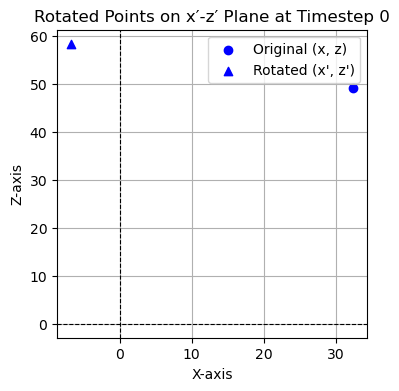

x, y, z =  [[ 2.66055805e+01 -5.50753012e+00  3.92007373e+01]
 [ 1.87036566e+02  3.76812730e+00  1.86329680e+02]
 [ 1.42912485e+02 -1.67964553e-01  1.81589589e+02]
 ...
 [ 2.57693101e-02  1.68120978e-04  2.97627468e-02]
 [ 3.07951270e-02  2.61238448e-04  3.53898173e-02]
 [ 3.29390859e-02  2.85628226e-04  3.75214745e-02]]
x', y', z' =  [[-4.81669117e+00 -5.50753012e+00  4.71312445e+01]
 [ 2.35079127e+01  3.76812730e+00  2.62961603e+02]
 [-7.24622294e+00 -1.67964553e-01  2.30968070e+02]
 ...
 [ 6.09311936e-04  1.68120978e-04  3.93637801e-02]
 [ 8.42299856e-04  2.61238448e-04  4.69048990e-02]
 [ 1.11446485e-03  2.85628226e-04  4.99159534e-02]]


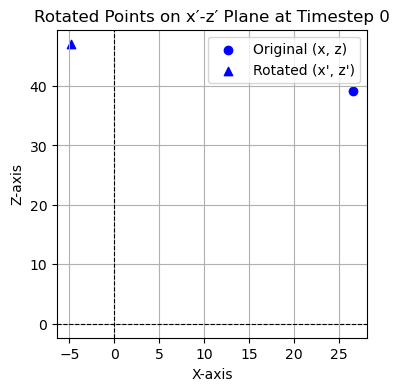

In [133]:
# convert accelerations from pvade coordinate system to that of experimental data
for case in cases:

    rotated_accel = pp.convert_sim_accel_coords_to_exp(tilt, sim_data[case])
    
    # Names for axes
    original_axes = ["x", "y", "z"]
    rotated_axes = ["x'", "y'", "z'"]
    
    # Choose a timestep to visualize (e.g., the first one):
    # timestep = 0  # Change this index to visualize other timesteps
    colors = ['blue', 'red', 'green']
    
    for timestep in range(1):
        plt.figure(figsize=(4, 4))
        
        # Scatter all points at the given timestep
        plt.scatter(sim_data[case]['accel-x'].iloc[timestep], sim_data[case]['accel-z'].iloc[timestep], color=colors[timestep], label="Original (x, z)", marker="o")
        plt.scatter(rotated_accel[timestep, 0], rotated_accel[timestep, 2], color=colors[timestep], label="Rotated (x', z')", marker="^")
        plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
        plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
        plt.xlabel("X-axis")
        plt.ylabel("Z-axis")
        plt.title(f"Rotated Points on x′-z′ Plane at Timestep {timestep}")
        plt.legend()
        plt.grid()
    plt.show()

    # assign calculated values to new columns in dataframe
    for n,comp in enumerate(['x','y','z']):
        sim_data[case][f'accel-{comp}-prime'] = rotated_accel[:,n]
    
        # reverse sign of z' accelerations to match DuraMAT sign convention
        # (our z' = their x, and positive x accelerations are towards the ground)
        if comp == 'z':
            sim_data[case][f'accel-{comp}-prime'] = -rotated_accel[:,n]
    

In [134]:
# interpolate simulated data to 50 Hz to match duramat loads signals
interp_sim_data = {}
for case in cases:
    new_time_index = exp_data['exp'].index #exp_data[exp_data.index>0.0].index
    interp_sim_data[case] = pp.interpolate_to_exp_freq(new_time_index, sim_data[case])

    
interp_sim_data[case]

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,def-x,...,def-z,u (m/s),v (m/s),w (m/s),vel_mag (m/s),fx_nd_calc,fz_nd_calc,accel-x-prime,accel-y-prime,accel-z-prime
Time,,,,,,,,,,,,,,,,,,,,,
0.02,7610.809001,-8.455311,7890.871269,3.494408,-0.003882,3.622995,133.559571,0.676241,137.286699,0.007613,...,0.008610,NaN,NaN,NaN,NaN,NaN,NaN,14.066378,0.676241,-191.018150
0.04,9989.005884,-29.491929,11406.119410,4.586327,-0.013541,5.236977,157.620512,1.144066,183.169619,0.019354,...,0.022026,NaN,NaN,NaN,NaN,NaN,NaN,3.005156,1.144066,-241.632581
0.06,4386.129306,-14.990491,4845.935984,2.013836,-0.006883,2.224951,-248.984273,-5.989251,-205.309270,0.022565,...,0.024659,NaN,NaN,NaN,NaN,NaN,NaN,-58.762764,-5.989251,317.320031
0.08,7333.138435,-6.369700,8541.042298,3.366919,-0.002925,3.921513,-56.781664,-8.054016,-35.352306,-0.002477,...,-0.003911,NaN,NaN,NaN,NaN,NaN,NaN,-20.773254,-8.054016,63.579988
0.10,2870.747686,8.098568,3455.259042,1.318068,0.003718,1.586439,70.186212,-1.532336,36.160447,-0.032405,...,-0.036788,NaN,NaN,NaN,NaN,NaN,NaN,30.522270,-1.532336,-72.815336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,2186.322281,-3.856363,2376.930957,1.003823,-0.001771,1.091338,0.020744,0.000052,0.023689,-0.027198,...,-0.031987,9.095477,9.705643e-08,-9.786964e-07,9.095477,0.986356,1.072349,0.000664,0.000052,-0.031481
29.72,2187.499875,-3.857639,2378.193129,1.004363,-0.001771,1.091918,0.020613,-0.000043,0.023656,-0.027306,...,-0.032110,9.095479,-5.475661e-07,-2.007592e-06,9.095479,0.986887,1.072918,0.000585,-0.000043,-0.031372
29.74,2188.812743,-3.861730,2379.592287,1.004966,-0.001773,1.092560,0.023479,0.000086,0.026987,-0.027401,...,-0.032219,9.095480,2.636798e-06,2.084707e-06,9.095480,0.987479,1.073549,0.000639,0.000086,-0.035765


In [136]:
cases

['turb_inflow', 'no_turb']

In [137]:
# merge dataframes
# create temp dataframe using existing function
tmpdata = {}

for case in cases:
    tmpdata[case] = pp.merge_dataframes(exp_data['exp'], sim_data[case], interp_sim_data[case])

# select and reorganize the data that I need
alldata = {}
alldata['exp'] = tmpdata[cases[0]]['exp']
for case in cases:
    alldata[case] = tmpdata[case]['sim_interp']


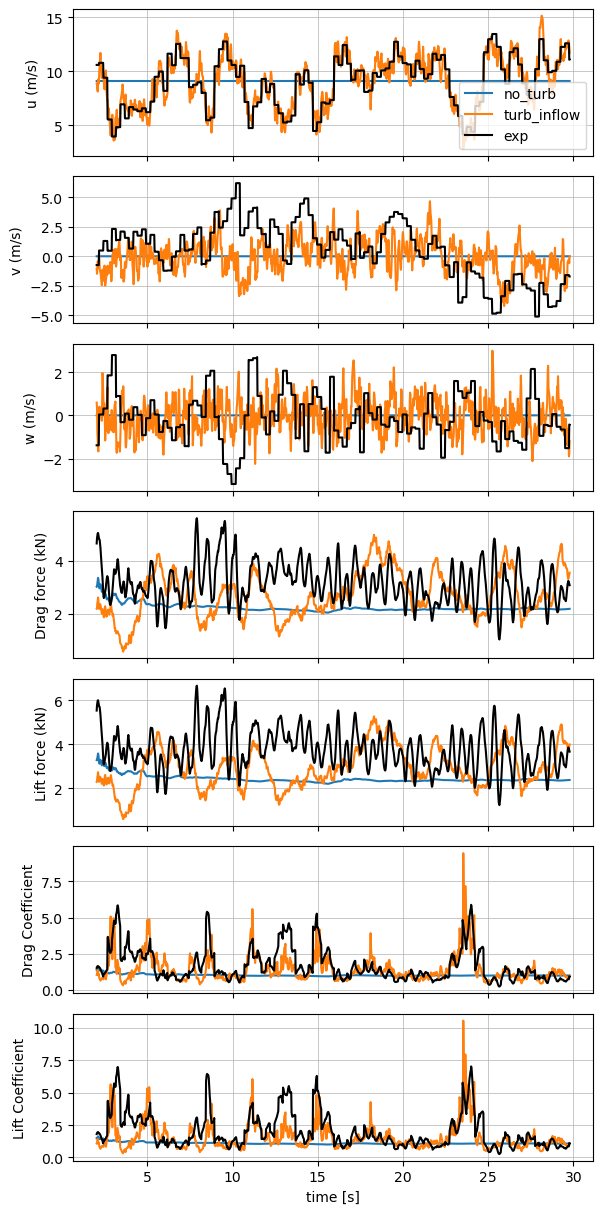

In [138]:
# plot drag and force for all cases on one plot
# colors = {'exp': 'k', 'noFSI': '#1f77b4', 'FSI': '#ff7f0e'}
colors = {'exp': 'k', 'no_turb': '#1f77b4', 'turb_inflow': '#ff7f0e'}

comps = ['u (m/s)','v (m/s)','w (m/s)','Drag force (kN)', 'Lift force (kN)','Drag Coefficient', 'Lift Coefficient']
# vars = ['sim_interp','exp']
# vars = ['exp']
cases = list(alldata.keys())[::-1]

fig, axs = plt.subplots(len(comps), 1, figsize=[6,len(comps)*1.75], sharex=True, sharey='row') #, dpi=300)

for row, comp in enumerate(comps):
    ax = axs[row]
    for case in cases:
        pltdata = alldata[case][comp][alldata[case][comp].index > 2.0]
        # ax.plot(pltdata, label=var, alpha=0.8, color=colors[var])
        ax.plot(pltdata, color=colors[case], label=case)
        ax.set_ylabel(f"{comp}")
    ax.grid(lw=0.5)
    # if row == 0:  # Add titles to the top row only
    #     # ax.set_title(f"Tracker Angle = {int(tilt)} deg")
    #     ax.set_title(f"{case}")

axs[-1].set_xlabel("time [s]")
axs[0].legend()
plt.tight_layout()

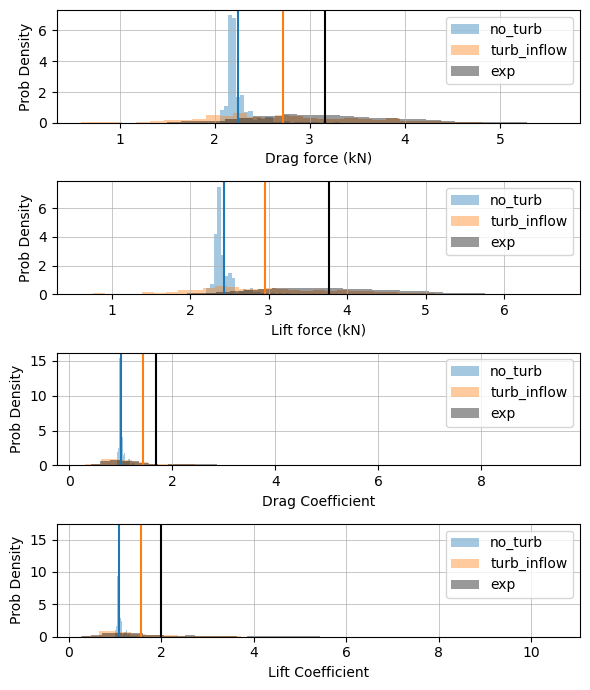

In [151]:
# plot drag and force for all cases on one plot
# comps = ['u (m/s)','v (m/s)','w (m/s)','Drag force (kN)', 'Lift force (kN)','Drag Coefficient', 'Lift Coefficient']
comps = ['Drag force (kN)', 'Lift force (kN)','Drag Coefficient', 'Lift Coefficient']

cases = list(alldata.keys())[::-1]

nbins = 30

fig, axs = plt.subplots(len(comps), 1, figsize=[6,len(comps)*1.75]) #, dpi=300)

for row, comp in enumerate(comps):
    ax = axs[row]
    for case in cases:
        pltdata = alldata[case][comp][alldata[case][comp].index > 2.0]
        ax.hist(pltdata, bins=nbins, density=True, color=colors[case], label=case, alpha=0.4) #colors_tilts[tilt])
        ax.axvline(np.mean(pltdata.values), color=colors[case], label='')
        ax.set_ylabel(f"{comp}")
    ax.grid(lw=0.5)
    ax.set_xlabel(comp)
    ax.legend()
    # if row == 0:  # Add titles to the top row only
    #     # ax.set_title(f"Tracker Angle = {int(tilt)} deg")
    #     ax.set_title(f"{case}")
for ax in axs:
    ax.set_ylabel('Prob Density')
# axs[0].legend()
plt.tight_layout()

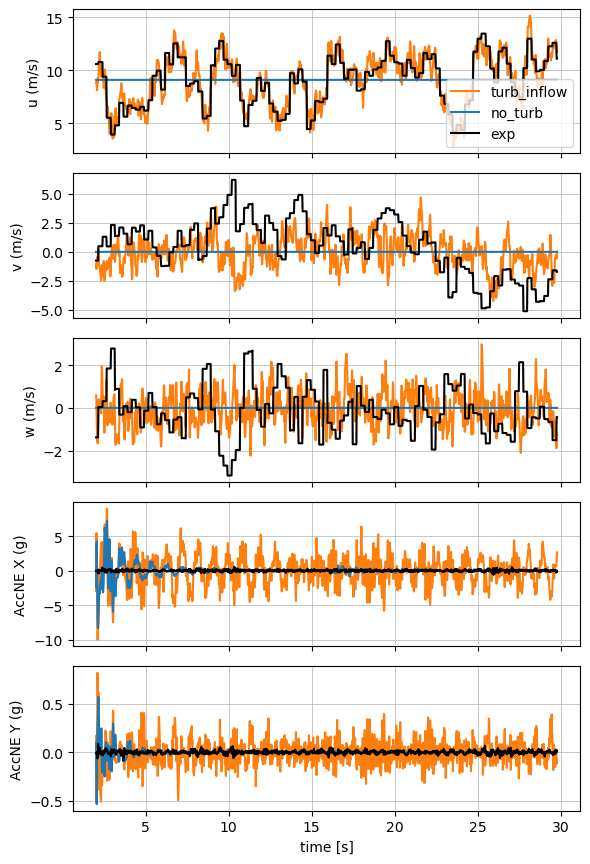

In [147]:
# plot drag and force for all cases on one plot
# colors = {'exp': 'k', 'noFSI': '#1f77b4', 'FSI': '#ff7f0e'}
colors = {'exp': 'k', 'no_turb': '#1f77b4', 'turb_inflow': '#ff7f0e'}

comps = ['u (m/s)','v (m/s)','w (m/s)','AccNE X (g)', 'AccNE Y (g)']
# vars = ['sim_interp','exp']
# vars = ['exp']
# cases = list(alldata.keys())[::-1]
cases = ['turb_inflow','no_turb','exp']

fig, axs = plt.subplots(len(comps), 1, figsize=[6,len(comps)*1.75], sharex=True, sharey='row') #, dpi=300)

for row, comp in enumerate(comps):
    ax = axs[row]
    for case in cases:
        pltdata = alldata[case][comp][alldata[case][comp].index > 2.0]
        # ax.plot(pltdata, label=var, alpha=0.8, color=colors[var])
        ax.plot(pltdata, color=colors[case], label=case)
        ax.set_ylabel(f"{comp}")
    ax.grid(lw=0.5)
    # if row == 0:  # Add titles to the top row only
    #     # ax.set_title(f"Tracker Angle = {int(tilt)} deg")
    #     ax.set_title(f"{case}")

axs[-1].set_xlabel("time [s]")
axs[0].legend()
plt.tight_layout()

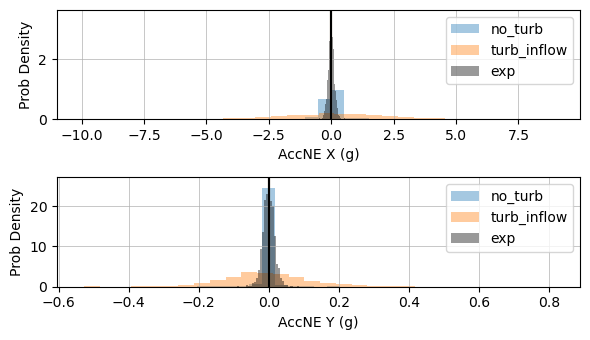

In [150]:
# plot drag and force for all cases on one plot
# comps = ['u (m/s)','v (m/s)','w (m/s)','Drag force (kN)', 'Lift force (kN)','Drag Coefficient', 'Lift Coefficient']
comps = ['AccNE X (g)', 'AccNE Y (g)']

cases = list(alldata.keys())[::-1]

nbins = 30

fig, axs = plt.subplots(len(comps), 1, figsize=[6,len(comps)*1.75]) #, dpi=300)

for row, comp in enumerate(comps):
    ax = axs[row]
    for case in cases:
        pltdata = alldata[case][comp][alldata[case][comp].index > 2.0]
        ax.hist(pltdata, bins=nbins, density=True, color=colors[case], label=case, alpha=0.4) #colors_tilts[tilt])
        ax.axvline(np.mean(pltdata.values), color=colors[case], label='')
        ax.set_ylabel(f"{comp}")
    ax.grid(lw=0.5)
    ax.set_xlabel(comp)
    ax.legend()
    # if row == 0:  # Add titles to the top row only
    #     # ax.set_title(f"Tracker Angle = {int(tilt)} deg")
    #     ax.set_title(f"{case}")
for ax in axs:
    ax.set_ylabel('Prob Density')
# axs[0].legend()
plt.tight_layout()

In [154]:
# compute stats
time_threshold = 8.0

vars_for_stats = ['u (m/s)', 'v (m/s)', 'w (m/s)', 'vel_mag (m/s)',
        'Drag force (kN)', 'Lift force (kN)', 
        'Drag Coefficient', 'Lift Coefficient',
        'AccNE X (g)', 'AccNE Y (g)']

statistics_list = []
for case in cases:
    for var in vars_for_stats:
            pltdata = alldata[case][var][alldata[case][var].index > time_threshold]
            
            stats = {
                'Case': f"{case}",
                'Var': f"{var}",
                'Mean': np.nanmean(pltdata.values),
                'Median': np.nanmedian(pltdata.values),
                'Max': np.max(pltdata.values),
                'Min': np.min(pltdata.values),
                'Std Dev': np.std(pltdata.values)
            }
            statistics_list.append(stats)
    
statistics_df = pd.DataFrame(statistics_list).set_index(['Case', 'Var'])
statistics_df.round(3)

Mean  Median     Max    Min  Std Dev
Case        Var                                                    
no_turb     u (m/s)           9.095   9.095   9.096  9.095    0.000
            v (m/s)          -0.000  -0.000   0.000 -0.000    0.000
            w (m/s)           0.000   0.000   0.000 -0.000    0.000
            vel_mag (m/s)     9.095   9.095   9.096  9.095    0.000
            Drag force (kN)   2.179   2.180   2.296  2.049    0.043
            Lift force (kN)   2.368   2.370   2.499  2.209    0.051
            Drag Coefficient  0.983   0.984   1.036  0.925    0.019
            Lift Coefficient  1.068   1.069   1.128  0.997    0.023
            AccNE X (g)       0.003   0.000   0.764 -0.801    0.138
            AccNE Y (g)      -0.000  -0.000   0.021 -0.027    0.003
turb_inflow u (m/s)           9.272   9.658  15.152  2.784    2.353
            v (m/s)           0.033   0.034   4.665 -4.218    1.479
            w (m/s)           0.036  -0.012   2.986 -2.243    0.773
            vel_mag (m/s)     9.432   9.823  15.180  2.898    2.340
            Drag force (kN)   2.788   2.680   4.969  1.159    0.813
            Lift force (kN)   3.028   2.918   5.271  1.263    0.869
            Drag Coefficient  1.397   1.126   9.461  0.370    0.910
            Lift Coefficient  1.521   1.217  10.535  0.410    1.004
            AccNE X (g)      -0.002   0.022   6.394 -5.798    1.923
            AccNE Y (g)       0.002  -0.004   0.396 -0.352    0.114
exp         u (m/s)           9.222   9.727  13.455  4.136    2.359
            v (m/s)           0.360   0.727   6.197 -5.110    2.650
            w (m/s)          -0.177  -0.261   2.690 -3.173    1.197
            vel_mag (m/s)     9.681  10.215  14.363  4.842    2.347
            Drag force (kN)   3.172   3.137   5.489  1.042    0.769
            Lift force (kN)   3.780   3.739   6.542  1.242    0.916
            Drag Coefficient  1.595   1.210   5.881  0.221    1.112
            Lift Coefficient  1.901   1.442   7.009  0.263    1.325
            AccNE X (g)      -0.001  -0.001   0.552 -0.609    0.129
            AccNE Y (g)       0.000  -0.000   0.067 -0.061    0.017

In [163]:
# compute errors
# keys = ['sim_interp']
comps = ['u (m/s)','v (m/s)','w (m/s)','vel_mag (m/s)','Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient', 'AccNE X (g)', 'AccNE Y (g)']
baseline = 'exp'

error_df = {}
error_list = []

for case in cases:
    mean_abs_err = {}
    mean_perc_err = {}
    stats_perc_err = {}
    for comp in comps:
        mean_abs_err[comp] = round(float(np.nanmean(alldata[case][comp].values - alldata[baseline][comp].values)),4)
        mean_perc_err[comp] = 100*round(float(np.nanmean((alldata[case][comp].values - alldata[baseline][comp].values)/alldata[baseline][comp].values)),3)
        stats_perc_err['mean'] = 100*((statistics_df.loc[(case, comp), 'Mean'] - statistics_df.loc[(baseline, comp), 'Mean']) / statistics_df.loc[(baseline, comp), 'Mean'])
        stats_perc_err['std'] = 100*((statistics_df.loc[(case, comp), 'Std Dev'] - statistics_df.loc[(baseline, comp), 'Std Dev']) / statistics_df.loc[(baseline, comp), 'Std Dev'])

        # Append results as a dictionary to the error list
        error_list.append({
            'Case': case,
            'Variable': comp,
            'Mean_Absolute_Error': mean_abs_err[comp],
            'Mean_Percent_Error [%]': mean_perc_err[comp],
            'Percent_Error_Mean [%]': stats_perc_err['mean'],
            'Percent_Error_Std [%]': stats_perc_err['std'],
            
        })

error_df = pd.DataFrame(error_list).set_index(['Variable','Case'])
error_df

,,Mean_Absolute_Error,Mean_Percent_Error [%],Percent_Error_Mean [%],Percent_Error_Std [%]
Variable,Case,,,,
u (m/s),no_turb,0.0865,9.9,-1.376429,-99.999703
v (m/s),no_turb,-0.4315,-100.0,-100.000280,-99.999878
w (m/s),no_turb,0.1174,-100.0,-100.000126,-99.999519
vel_mag (m/s),no_turb,-0.3113,4.0,-6.050481,-99.999702
Drag force (kN),no_turb,-0.8570,-22.9,-31.289891,-94.430280
Lift force (kN),no_turb,-1.2572,-29.5,-37.356634,-94.395069
Drag Coefficient,no_turb,-0.6652,-13.5,-38.353149,-98.262063
Lift Coefficient,no_turb,-0.8995,-21.1,-43.796244,-98.251077
AccNE X (g),no_turb,0.2419,-511.9,-445.032264,7.312209


In [171]:
error_df.columns

Index(['Mean_Absolute_Error', 'Mean_Percent_Error [%]',
       'Percent_Error_Mean [%]', 'Percent_Error_Std [%]'],
      dtype='object')

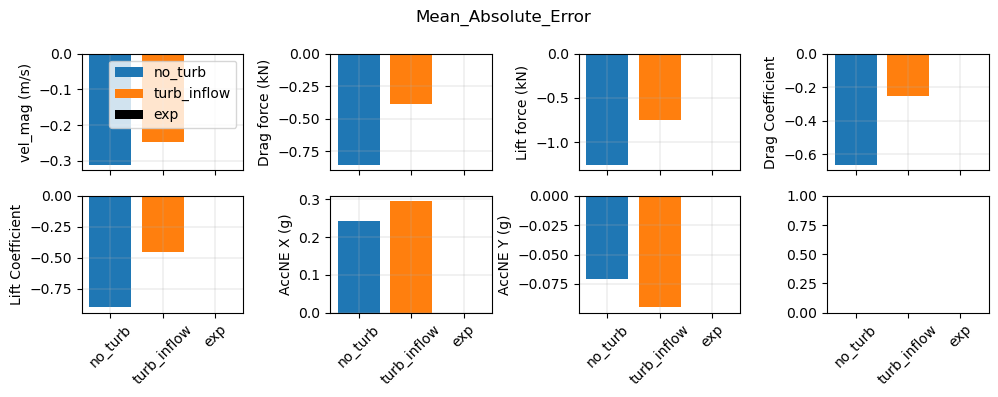

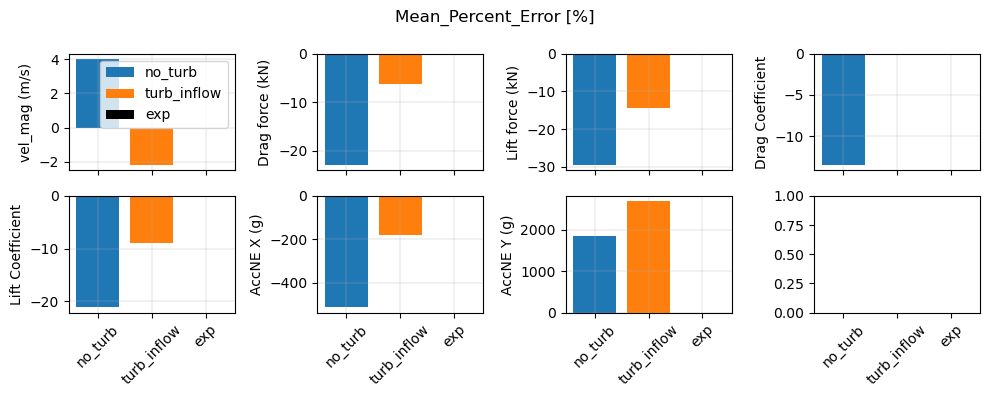

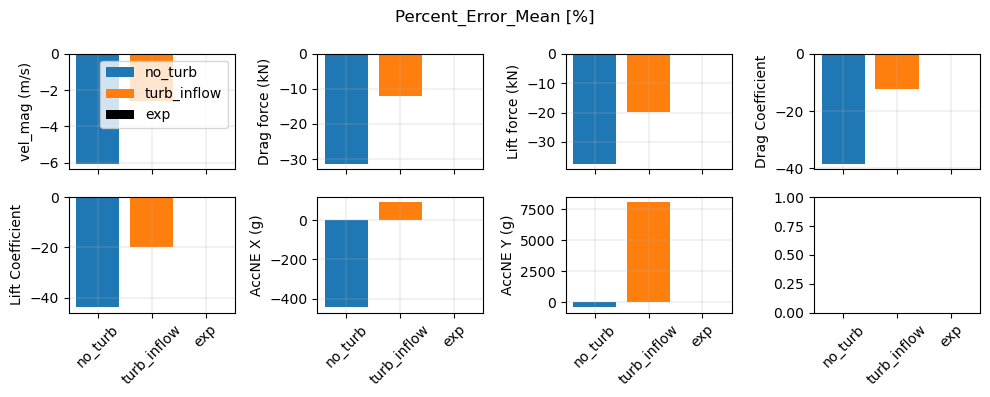

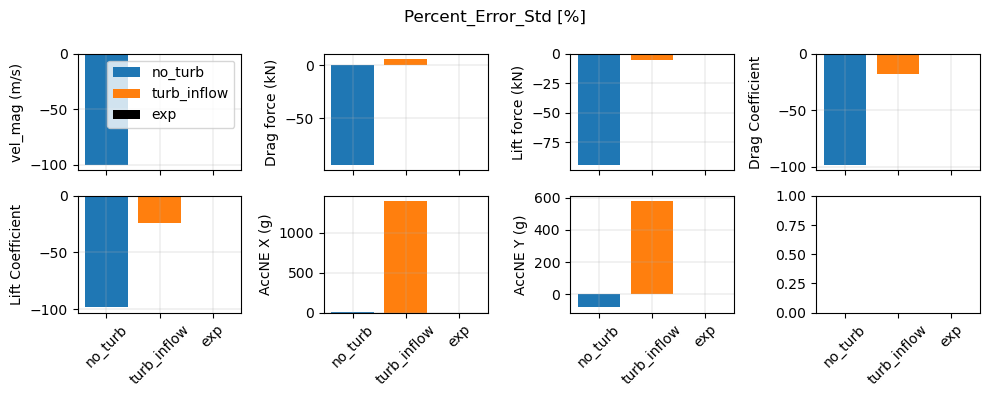

In [178]:
# plot errors vs tracker angle
vars = ['vel_mag (m/s)','Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient', 'AccNE X (g)', 'AccNE Y (g)']
# error_types = ['Mean_Percent_Error [%]', 'Percent_Error_Mean [%]']
# error_types = ['Mean_Absolute_Error', 	'Mean_Percent_Error [%]']
error_types = error_df.columns

for error_type in error_types:
    fig, axs = plt.subplots(2,4,figsize=[10,4], sharex=True)
    plt.suptitle(error_type)
    # plt.suptitle(error_type)
    for case in cases:
        for var,ax in zip(vars, axs.ravel()):
            ax.bar(case,error_df.loc[(var,case)][error_type], color=colors[case], label=case)
            
            ax.set_ylabel(var)
            ax.grid(lw=0.25)
    axs[0,0].legend()
    for ax in axs[-1, :]:
        for label in ax.get_xticklabels():
            label.set_rotation(45)  # Rotate x-axis labels by 45 degrees
    plt.tight_layout()

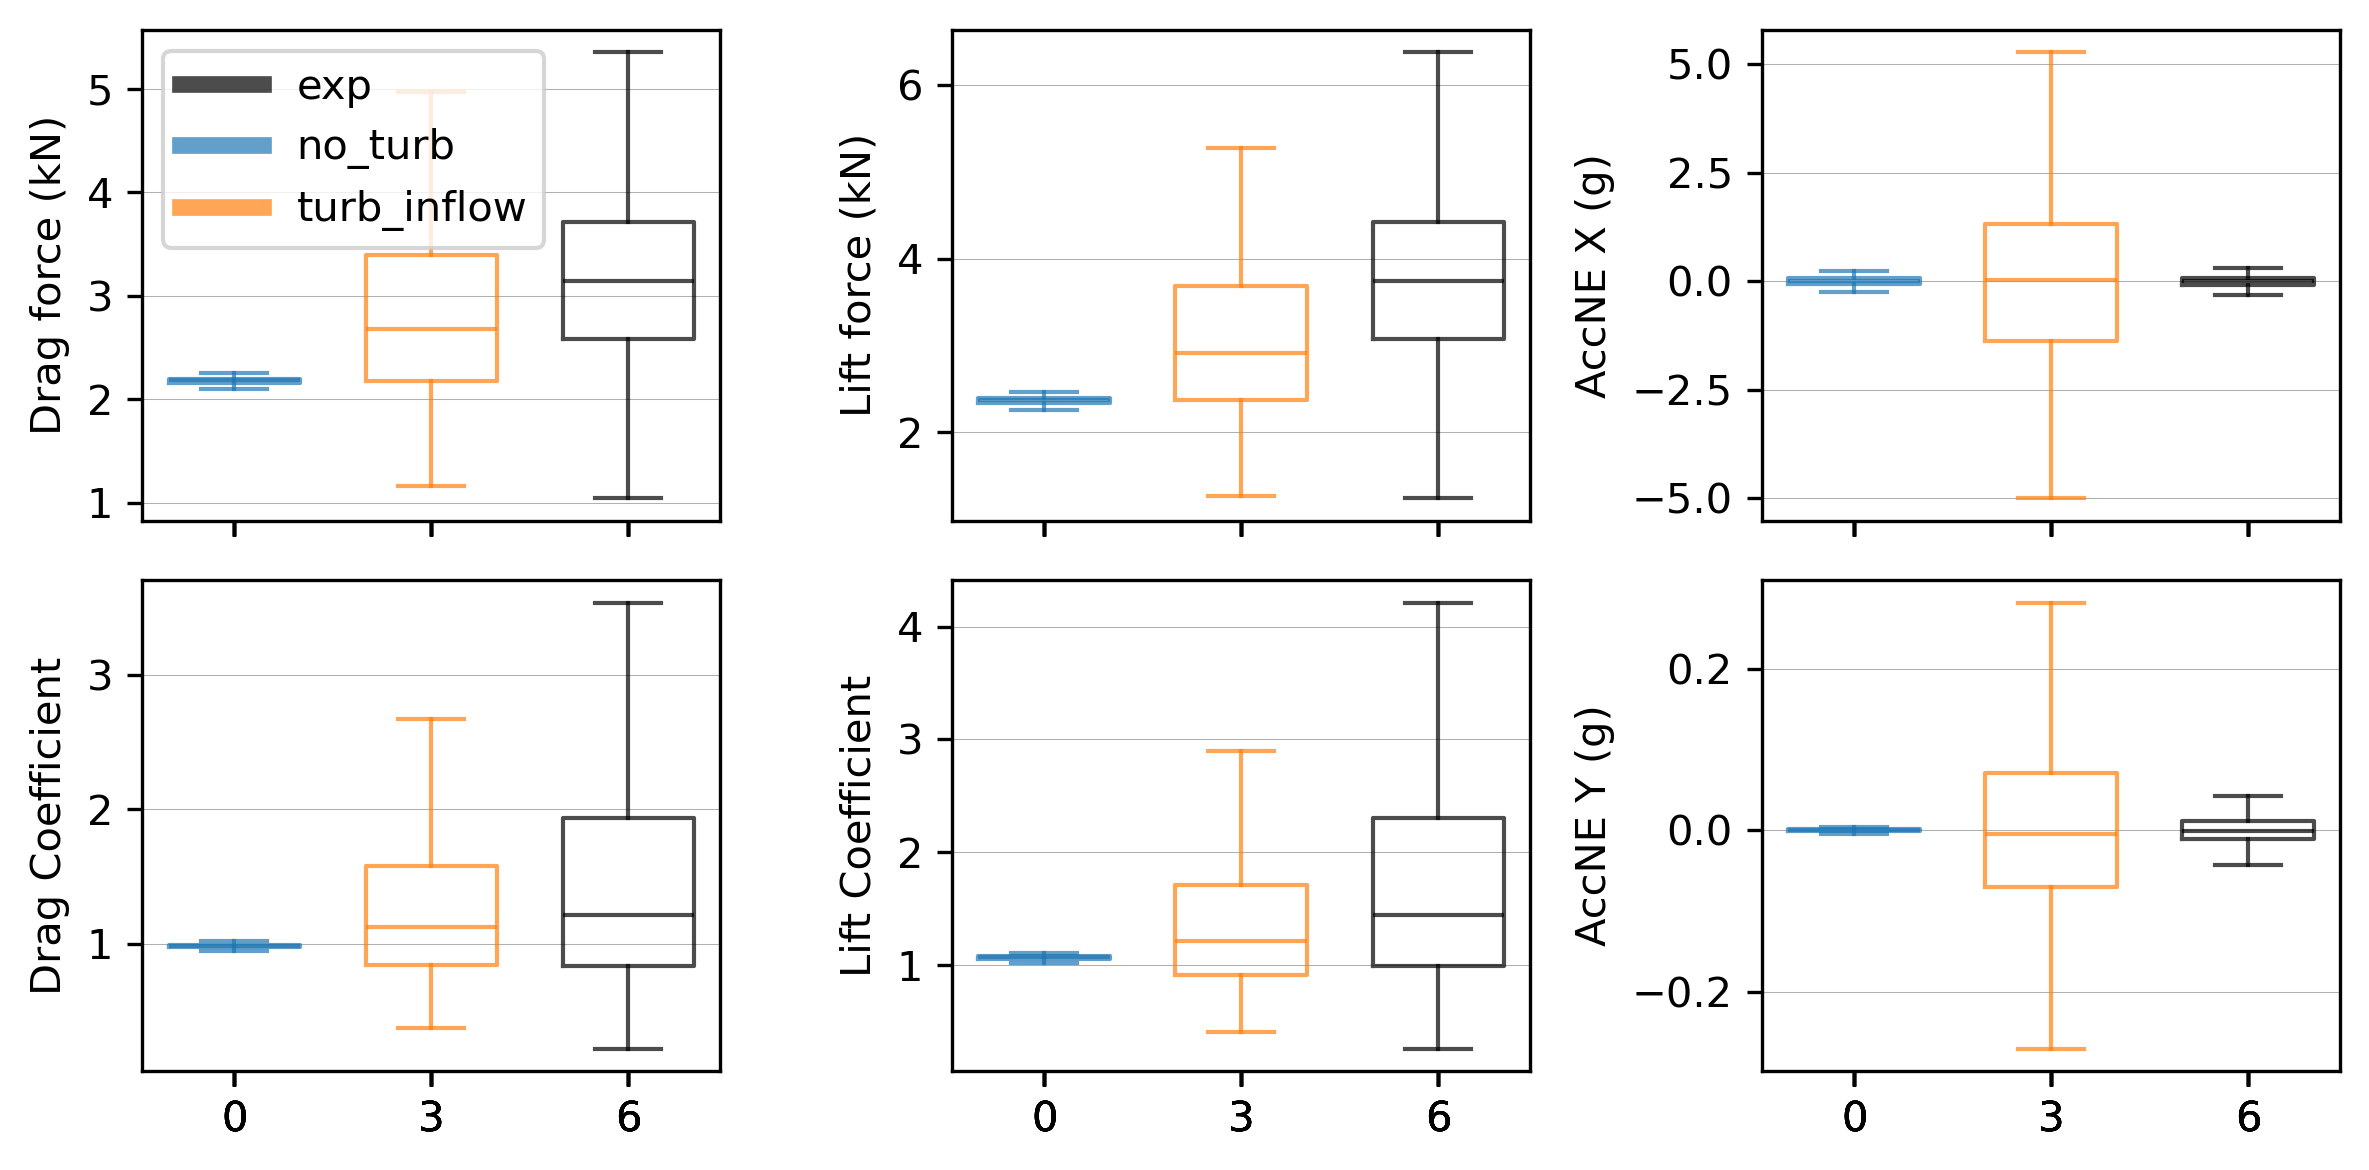

In [188]:
# box plots of all loads
comps = ['Drag force (kN)', 'Lift force (kN)', 'AccNE X (g)', 'Drag Coefficient', 'Lift Coefficient', 'AccNE Y (g)']
# vars = ['sim_interp','exp']
# vars = ['exp']

# colors = {'exp': 'k', 'sim_interp': 'goldenrod'}

fig, axs = plt.subplots(2, 3, figsize=[8, 4], sharex=True, dpi=300)
for comp, ax in zip(comps, axs.ravel()):
    for i, case in enumerate(cases):
        # for var in vars:
            pltdata = alldata[case][comp][alldata[case][comp].index > time_threshold]
            bp = ax.boxplot(
                pltdata.values,
                positions=[i*3],
                widths=2.0,
                showfliers=False, 
                patch_artist=False  # No facecolor/filled boxes
            )
            
            # # Customize line properties
            for element in ['boxes', 'whiskers', 'caps', 'medians']:
                [line.set_color(colors[case]) for line in bp[element]]
                [line.set_alpha(0.7) for line in bp[element]]

    ax.grid(lw=0.25,axis='y')
    ax.set_ylabel(comp)
    # ax.set_xticks(range(len(cases)))  # Set numeric tick positions
    # ax.set_xticklabels(cases)  # Assign case labels to x-ticks
    
axs[0, 0].legend([plt.Line2D([0], [0], color=color, alpha=0.7, lw=4) for color in colors.values()], colors.keys())

# for ax in axs[-1, :]:
#     ax.set_xlabel('Case')
plt.tight_layout()